In [48]:
from sklearn.datasets import make_classification
import torch

In [49]:
X, y = make_classification(
    n_samples=10,       # Number of samples
    n_features=2,       # Number of features
    n_informative=2,    # Number of informative features
    n_redundant=0,      # Number of redundant features
    n_classes=2,        # Number of classes
    random_state=42     # For reproducibility
)

In [50]:
X

array([[ 1.06833894, -0.97007347],
       [-1.14021544, -0.83879234],
       [-2.8953973 ,  1.97686236],
       [-0.72063436, -0.96059253],
       [-1.96287438, -0.99225135],
       [-0.9382051 , -0.54304815],
       [ 1.72725924, -1.18582677],
       [ 1.77736657,  1.51157598],
       [ 1.89969252,  0.83444483],
       [-0.58723065, -1.97171753]])

In [51]:
X.shape


(10, 2)

In [52]:
y

array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

In [53]:
y.shape

(10,)

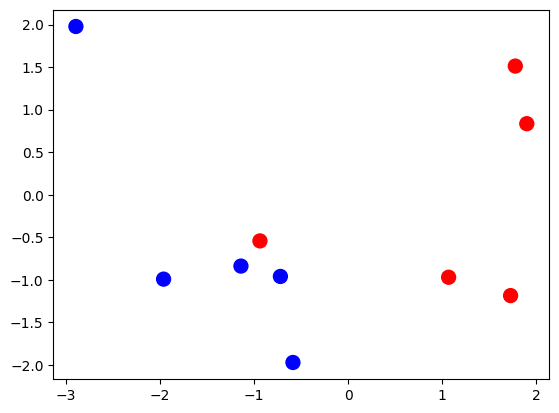

In [54]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=100)

In [55]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

In [56]:
from torch.utils.data import Dataset, DataLoader

In [57]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [58]:
dataset = CustomDataset(X,y)

In [59]:
len(dataset)

10

In [62]:
dataset[2]

(tensor([-2.8954,  1.9769]), tensor(0))

In [63]:
dataloader = DataLoader(dataset,batch_size=2,shuffle=True)

In [64]:
for batch_features,batch_labels in dataloader:
    print(batch_features)
    print(batch_labels)
    print("-"*50)



tensor([[-0.7206, -0.9606],
        [ 1.7273, -1.1858]])
tensor([0, 1])
--------------------------------------------------
tensor([[1.8997, 0.8344],
        [1.7774, 1.5116]])
tensor([1, 1])
--------------------------------------------------
tensor([[-0.5872, -1.9717],
        [-1.1402, -0.8388]])
tensor([0, 0])
--------------------------------------------------
tensor([[-1.9629, -0.9923],
        [-2.8954,  1.9769]])
tensor([0, 0])
--------------------------------------------------
tensor([[ 1.0683, -0.9701],
        [-0.9382, -0.5430]])
tensor([1, 1])
--------------------------------------------------
